In [4]:
import numpy as np
from math import pow
import matplotlib.pyplot as plt
plt.style.use('bmh')
import os
from utils import *
from utils import grid_to_real_projection
from simulation import *
from tqdm import tqdm
from pprint import pprint

from models import DistanceCellModel, VectorCellModel, NestedModel
from simulation import run_load_simulation
OUTPUT_DIR = 'simulation_outputs'

# ================= MODEL & SIMULATION PARAMETERS =================
N_SIM_ROUND = 5
N_TRIALS = 100
ARENA_WIDTH = 100
STEP_SIZE = 1
CONV_THRESH = STEP_SIZE * 1.5
HEX_PROJ=True
model_names = ['nm', 'dcm', 'vcm']

Loading simulation data from simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-0.pkl
Loading simulation data from simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-1.pkl
Loading simulation data from simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-2.pkl
Loading simulation data from simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-5.pkl
Loading simulation data from simulation_outputs/round-5/global/nm_trials-100_shear-global_a-0_b-10.pkl
Loading simulation data from simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-0.pkl
Loading simulation data from simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-1.pkl
Loading simulation data from simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-2.pkl
Loading simulation data from simulation_outputs/round-5/global/dcm_trials-100_shear-global_a-0_b-5.pkl
Loading simulation data from simulation_outputs/round-5/global/dcm_trials-100

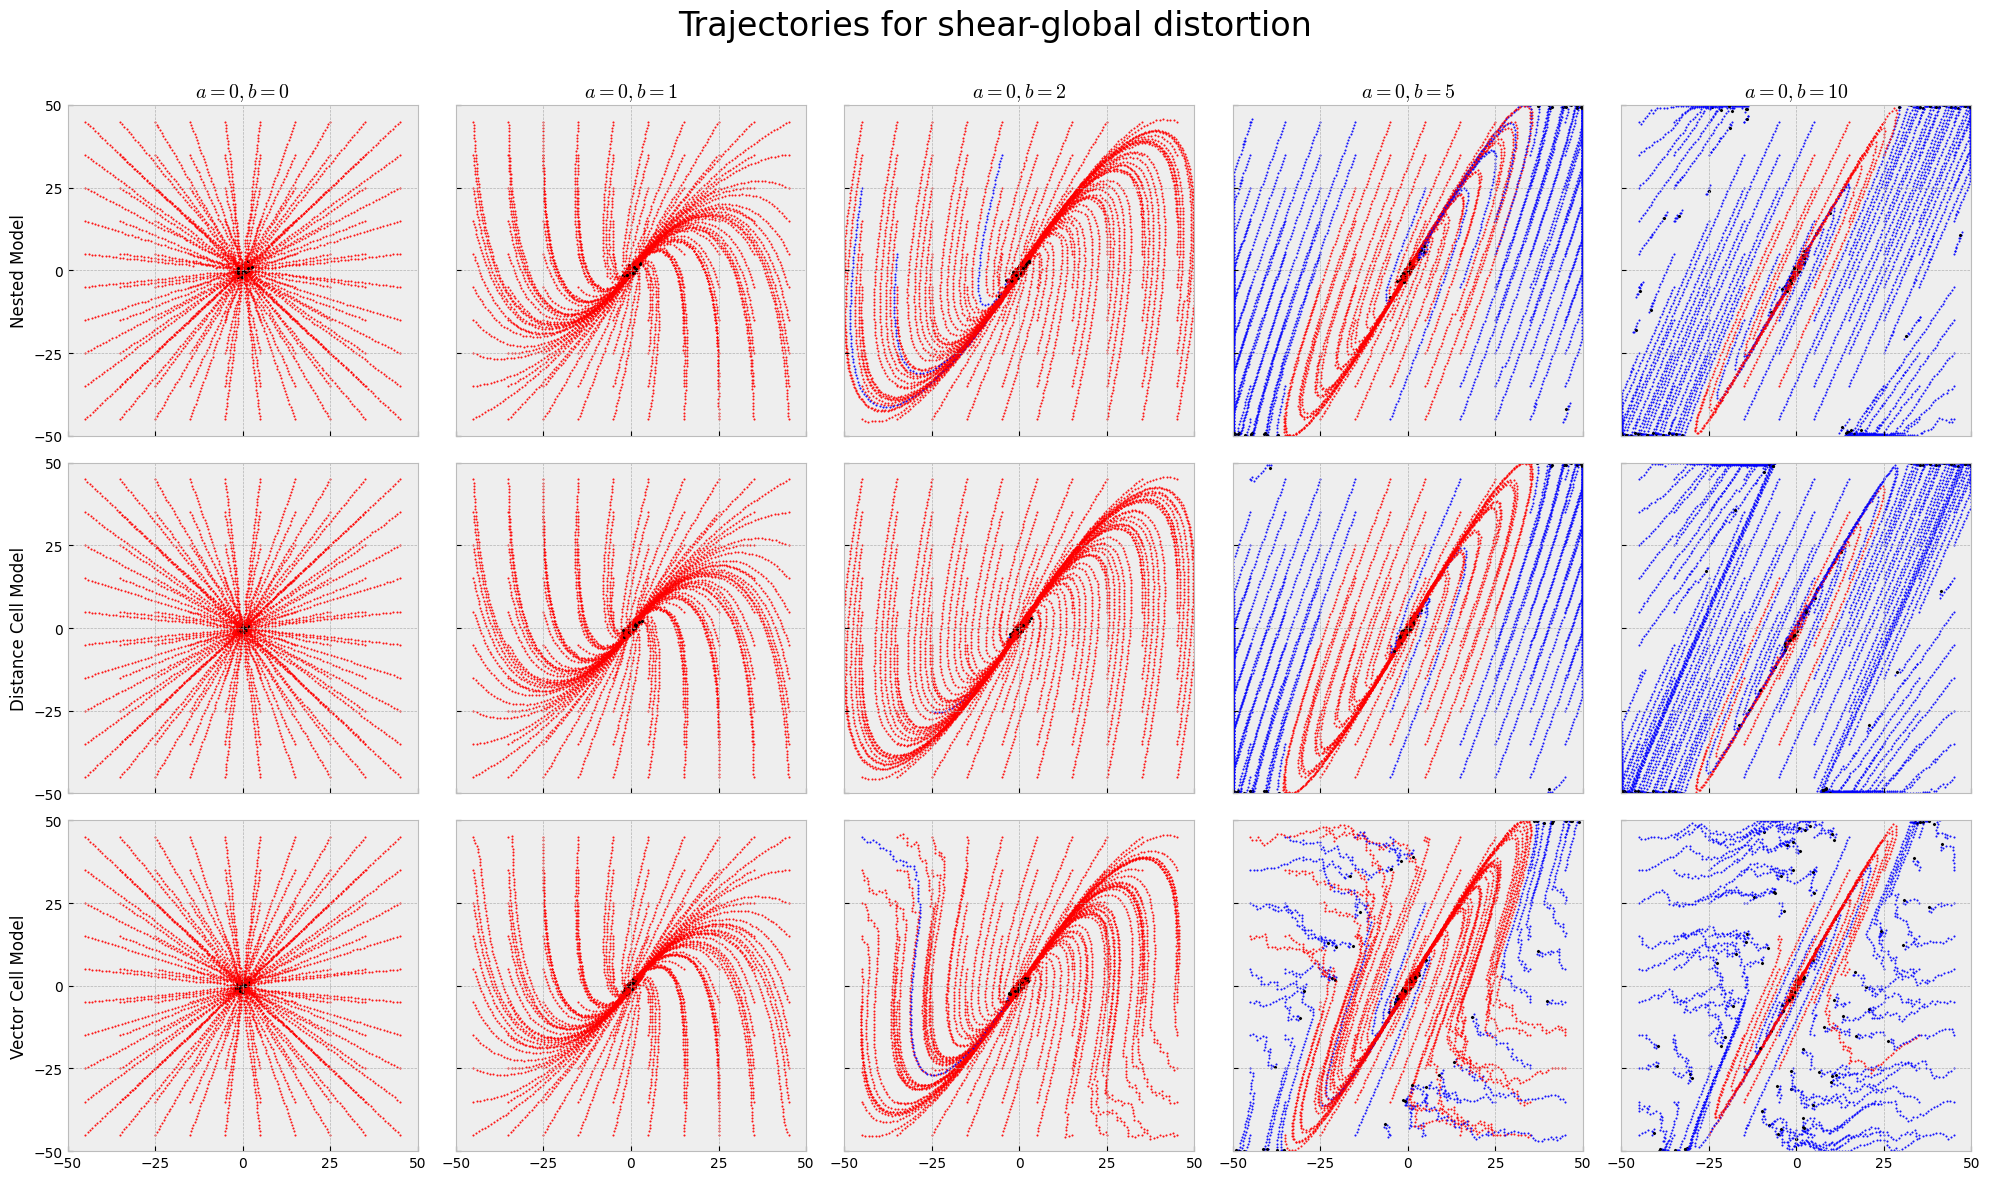

In [5]:
shear_global_params = get_param_dict({'a': [0], 'b': [0, 1, 2, 5, 10]}, 
                                     'shear-global', incl_undistorted=False)
plot_trajectories_all_models(shear_global_params, 
                             model_names, 
                             arena_width=ARENA_WIDTH, 
                             step_size=STEP_SIZE, 
                             convergence_threshold=CONV_THRESH, 
                             n_trials=N_TRIALS, 
                             hexagonal_projection=HEX_PROJ, 
                             n_sim_round= N_SIM_ROUND)

In [ ]:
plot_error_bars(distortion='shear-global', distortion_params=shear_global_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-modular', distortion_params=shear_modular_params, n_trials=N_TRIALS, model_names=model_names)
plot_error_bars(distortion='shear-local', distortion_params=shear_local_params, n_trials=N_TRIALS, model_names=model_names)

In [2]:
arena_width = 100
n_trials = 100
border_offset = 0.05 * arena_width
square_half_width = (arena_width / 2)
offset_square_half_width = square_half_width - border_offset

XS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
YS = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
start_locs = np.array(np.meshgrid(XS, YS)).T.reshape(-1, 2)
print('start_locs:', start_locs.shape)

print('Projecting evenly spaced start locations onto hexagonal grid axes...')
PX, PY = np.meshgrid(XS, YS)
original_grid = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space
start_locs = project_onto_axis_back(original_grid, l1=1, l2=2)  # (2, N) — parallelogram in real space
start_locs = start_locs.T  # (N, 2)
print('start_locs:', start_locs.shape)


start_locs: (100, 2)
Projecting evenly spaced start locations onto hexagonal grid axes...
start_locs: (100, 2)


### Projection of coordinate system into GC space

In [ ]:
offset_square_half_width = 10
n_trials = 10
xs = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
ys = np.linspace(-offset_square_half_width, offset_square_half_width, int(np.sqrt(n_trials)))
XS, YS = np.meshgrid(xs, ys)
real_start_locs = np.array([XS.ravel(), YS.ravel()]).T.reshape(-1, 2)
real_start_locs


array([[-10., -10.],
       [  0.,   0.],
       [ 10.,  10.]])

This are my original start locations:
This is the reconstructed start locations:
This should match my original start locations:


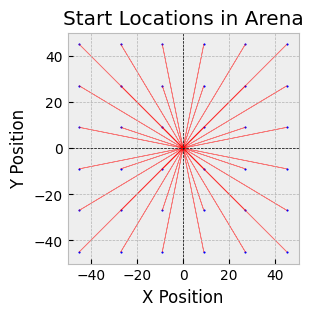

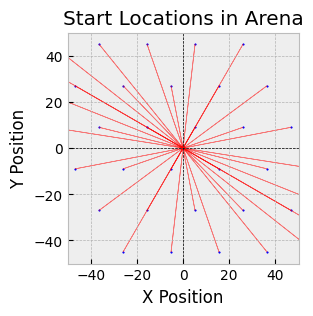

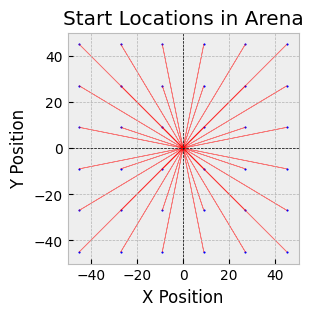

In [12]:
def plot_start_locations(X, Y, square_half_width):
    plt.figure(figsize=(3, 3))
    plt.scatter(X, Y, c='blue', label='Start Locations', s=1)
    plt.xlim(-square_half_width, square_half_width)
    plt.ylim(-square_half_width, square_half_width)
    # Calculate vector from each point to [0,0]
    for x, y in zip(X, Y):
        vec = - np.array([x, y])
        plt.arrow(x, y, vec[0], vec[1], head_width=1, head_length=1, fc='red', ec='red', alpha=0.5)
    plt.axhline(0, color='black', linewidth=0.5, linestyle='--')
    plt.axvline(0, color='black', linewidth=0.5, linestyle='--')
    plt.title('Start Locations in Arena')
    plt.xlabel('X Position')
    plt.ylabel('Y Position')
    plt.gca().set_aspect('equal', adjustable='box')
    plt.grid(True)

    
# 1. Grid of start locations in real space
arena_width = 100
n_trials = 36

square_half_width = (arena_width / 2)
offset = 0.1 * square_half_width  # to avoid points on the edge

# Generate pos_xy_mat
XS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
YS = np.linspace(-square_half_width + offset, square_half_width - offset, int(np.sqrt(n_trials)))
PX, PY = np.meshgrid(XS, YS)
original_grid = np.array([PX.ravel(), PY.ravel()])  # (2, N) — evenly spaced in axis space
print('This are my original start locations:')
plot_start_locations(original_grid[0, :], original_grid[1, :], square_half_width)

# Convert to real 2D positions to pass to navigation
proj_grid = real_to_grid_projection(original_grid, l1=1, l2=2)  # (2, N) — parallelogram in real space
print('This is the reconstructed start locations:')
plot_start_locations(proj_grid[0, :], proj_grid[1, :], square_half_width)


back_original_grid = grid_to_real_projection(proj_grid)
print('This should match my original start locations:')
plot_start_locations(back_original_grid[0, :], back_original_grid[1, :], square_half_width)
